In [9]:
import matplotlib.pyplot as plt
#import gridspec
import numpy as np
import matplotlib.gridspec as gridspec
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.colors import ListedColormap
import matplotlib.cm as cm
from scipy.stats import pearsonr


/tmp/ipykernel_2655685/3049346908.py:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap(cmap_user)
/tmp/ipykernel_2655685/3049346908.py:111: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = plt.cm.get_cmap("tab10", len(animal_names))


Sample size:  120
p value:  3.255222738511406e-25
Sample size:  53
p value:  0.00014148149770708556


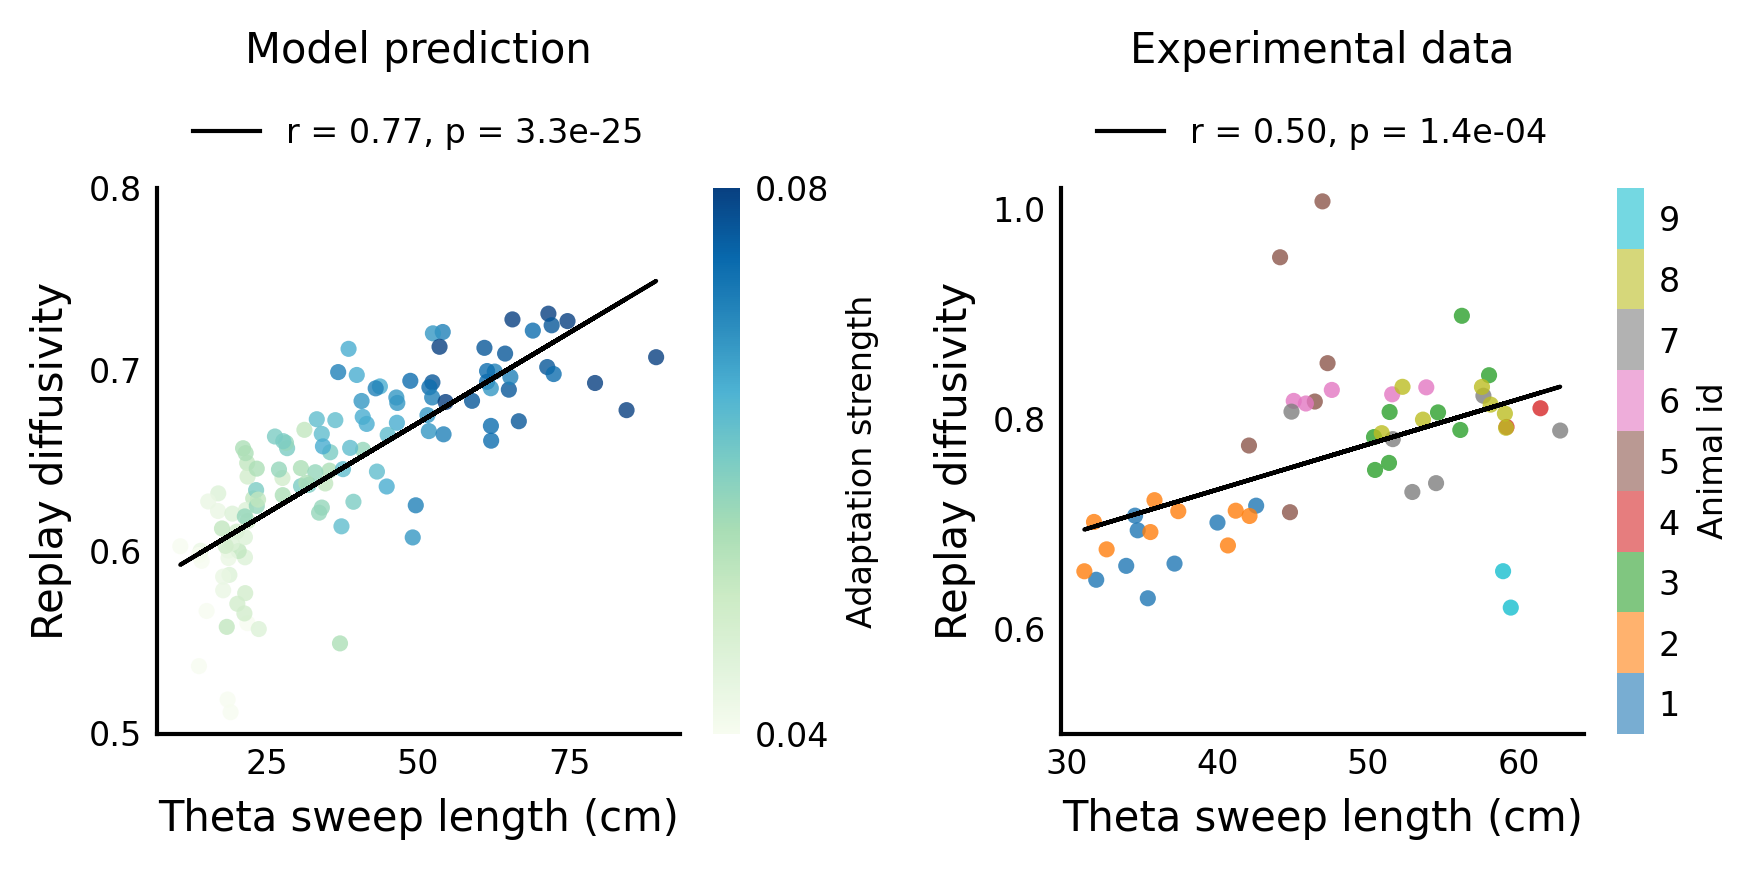

In [10]:
fig = plt.figure(figsize=(6, 3), dpi=300)
gs = gridspec.GridSpec(1, 2)
labelsize = 10
ticksize = 8
realtraj_color = "#009FB9"

# ax 3
ax0 = plt.subplot(gs[0])

# load the data from the pickle file
import pickle

with open(
    "/media/zilong/3C145D75145D335E/AdaptiveAttractorForSequences/ExpData/sweep_replay_correlation_model.pkl",
    "rb",
) as f:
    M, MeanSweep, MeanSweepAmp, DiffusionExp = pickle.load(f)
cmap_user = "GnBu"
# Create a colormap scalar map
norm = Normalize(vmin=np.min(M), vmax=np.max(M))
cmap = cm.get_cmap(cmap_user)
sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  # An empty array to create the color mapping

simulation_nums = DiffusionExp.shape[0]
for i in range(simulation_nums):
    ax0.scatter(
        MeanSweepAmp[i, :],
        DiffusionExp[i, :],
        c=M,
        cmap=cmap_user,
        s=15,
        alpha=0.8,
        edgecolors="none",
    )
# add linear fit line to the plot using numpy.polyfit
# convert MeanSweep and DiffusionExp from 2D array to 1D array
exp_np = DiffusionExp.flatten()
sweep_len_np = MeanSweepAmp.flatten()
slope, intercept = np.polyfit(sweep_len_np, exp_np, 1)
# pearson test
corr, p = pearsonr(sweep_len_np, exp_np)
#print p value, and sample size and stats
print("Sample size: ", len(sweep_len_np))
print("p value: ", p)


if p < 0.001:
    ax0.plot(
        sweep_len_np,
        sweep_len_np * slope + intercept,
        "k-",
        label="r = %.2f, p = %.1e" % (corr, p),
        linewidth=1,
    )
else:
    ax0.plot(
        sweep_len_np,
        sweep_len_np * slope + intercept,
        "k-",
        label="r = %.2f, p = %.3f" % (corr, p),
        linewidth=1,
    )

# legend
ax0.legend(fontsize=ticksize, frameon=False, loc="center", bbox_to_anchor=(0.5, 1.1))

# Add a colorbar
cbar = plt.colorbar(sm, ax=ax0)
cbar.set_label("Adaptation strength", fontsize=ticksize)
# set colorbar box off
cbar.outline.set_visible(False)
# remove cbar tick labels
# cbar.ax.set_yticklabels([])

# show only the min and max values
vmin, vmax = np.min(M), np.max(M)
cbar.set_ticks([vmin, vmax])
cbar.set_ticklabels([f"{vmin:.2f}", f"{vmax:.2f}"])

ax0.set_xlabel("Theta sweep length (cm)", fontsize=labelsize)
ax0.set_ylabel("Replay diffusivity", fontsize=labelsize)
# ad title as 'Model prediction'
ax0.set_title("Model prediction", fontsize=labelsize, pad=30)
# change the xticks from meter to centermeter by times 100
ax0.set_xticks([0.25, 0.5, 0.75])
ax0.set_xticklabels([25, 50, 75])
# set y ticks
ax0.set_yticks([0.5, 0.6, 0.7, 0.8])

# ax1
ax1 = plt.subplot(gs[1])

# load real data: ./sweep_replay_correlation_realdata.pkl
# !!! need to run SeeepAwakeReplayCorrelation.ipynb first to generate the pickle file if not exist
with open(
    "/media/zilong/3C145D75145D335E/AdaptiveAttractorForSequences/ExpData/sweep_replay_correlation_realdata.pkl",
    "rb",
) as f:
    (
        animal_names,
        all_sweep_len_perday_concat,
        all_sweep_amp_perday_concat,
        all_sweep_ahead_perday_concat,
        all_sweep_behind_perday_concat,
        all_exponent_perday_concat,
        all_ave_activespeed_perday_concat,
    ) = pickle.load(f)

# get the color for each animal
colors = plt.cm.get_cmap("tab10", len(animal_names))
color_dict = {}
for i, name in enumerate(animal_names):
    color_dict[name] = colors(i)

# plot the real data
for name in animal_names:
    ax1.scatter(
        np.array(all_sweep_amp_perday_concat[name]),
        np.array(all_exponent_perday_concat[name]),
        s=15,
        alpha=0.8,
        color=color_dict[name],
        edgecolors="none",
    )

# add linear fit line to the plot using numpy.polyfit
# convert all_sweep_len_perday_concat and all_exponent_perday_concat to numpy array
exp_np = np.concatenate(list(all_exponent_perday_concat.values()))
sweep_len_np = np.concatenate(list(all_sweep_amp_perday_concat.values()))
slope, intercept = np.polyfit(sweep_len_np, exp_np, 1)
# pearson test
corr, p = pearsonr(sweep_len_np, exp_np)
# if p<0.001, then add label as 'r = %.2f, p < 0.001'; else add label as 'r = %.2f, p = %.3f'

#print p value, and sample size and stats
print("Sample size: ", len(sweep_len_np))
print("p value: ", p)

if p < 0.001:
    ax1.plot(
        sweep_len_np,
        sweep_len_np * slope + intercept,
        "k-",
        label="r = %.2f, p = %.1e" % (corr, p),
        linewidth=1,
    )
else:
    ax1.plot(
        sweep_len_np,
        sweep_len_np * slope + intercept,
        "k-",
        label="r = %.2f, p = %.3f" % (corr, p),
        linewidth=1,
    )

# legend
ax1.legend(fontsize=ticksize, frameon=False, loc="center", bbox_to_anchor=(0.5, 1.1))


# add colorbar with alpha 0.8
cmap = ListedColormap(color_dict.values())
# Create a ScalarMappable with the colormap and normalize it
sm = ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=len(color_dict)))
# Set the colorbar properties
cbar = plt.colorbar(sm, ax=ax1, ticks=list(range(len(color_dict))), alpha=0.6)
# Set colorbar ticks by adding 1 to each tick
ticks = list(range(len(color_dict)))
cbar.set_ticks([tick + 0.5 for tick in ticks])
# set tick labels by adding 1 to each tick
cbar.set_ticklabels(list(range(1, len(color_dict) + 1)))
# Set colorbar ticklabels by adding 1 to each tick
# Set colorbar label
cbar.set_label("Animal id", fontsize=ticksize)
# remove the box of the colorbar
cbar.outline.set_visible(False)

ax1.set_xlabel("Theta sweep length (cm)", fontsize=labelsize)
ax1.set_ylabel("Replay diffusivity", fontsize=labelsize)
ax1.set_title("Experimental data", fontsize=labelsize, pad=30)
ax1.set_yticks([0.6, 0.8, 1.0])
ax1.set_ylim(0.5, 1.02)

# for all axes, set upper and right spine off, axis line width 1.0
all_axes = fig.get_axes()
for ax in all_axes:
    ax.tick_params(labelsize=ticksize)
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)
    # axis line width 1.0
    ax.spines["bottom"].set_linewidth(1.0)
    ax.spines["left"].set_linewidth(1.0)
    # remove the tick bars on the left and bottom
    ax.tick_params(axis="both", which="both", length=0)

plt.tight_layout()
